**Loan Approval Prediction Project Description:**

***This project focuses on building a machine learning–based system to predict whether a loan application will be approved or rejected based on an applicant’s financial and personal details. The dataset is carefully cleaned, preprocessed, and enhanced through feature engineering, where important financial ratios such as loan-to-income ratio and asset-to-loan ratio are created to better represent an applicant’s creditworthiness. To handle real-world class imbalance, SMOTE is applied, ensuring fair learning for both approved and rejected cases. A Random Forest classifier is trained and optimized using GridSearchCV to achieve high predictive performance. The model is evaluated using metrics such as accuracy, ROC-AUC, confusion matrix, and classification report to ensure reliability. Feature importance analysis is performed to understand the key factors influencing loan approval decisions. Finally, the complete preprocessing and prediction pipeline is saved for future deployment in automated loan approval systems.*** *italicized text*

**Dataset Description – Loan Approval Dataset:**

***The loan approval dataset consists of 4,269 rows and 13 columns, where each row represents a unique loan application submitted by an applicant. The dataset includes a mix of demographic details (such as education and self-employment status), financial attributes (income, loan amount, asset values), and a unique loan ID for identification. The target variable, loan_status, indicates whether a loan was approved or rejected, making this a binary classification problem. The dataset reflects real-world financial data characteristics, including varying income levels, asset distributions, and class imbalance, making it suitable for building and evaluating practical machine learning models for loan approval prediction.***

**IMPORTING LIBRARIES**

 **DESCRIPTION:**

We start by importing essential Python libraries for data manipulation, visualization, modeling, and evaluation. We also import SMOTE for handling class imbalance and joblib for saving the model.

**NumPy (numpy):**

Used for numerical computations such as mathematical operations, handling arrays, and replacing infinite values.

**Pandas (pandas):**

Used for loading the dataset, cleaning data, handling missing values, and feature engineering using DataFrames.

**Matplotlib & Seaborn:**

Used for data visualization such as histograms, box plots, heatmaps, ROC curves, and feature importance plots.

**Scikit-learn Modules:**

***1.train_test_split:*** Splits dataset into training and testing sets.

***2.GridSearchCV:*** Performs hyperparameter tuning using cross-validation.

***3.OneHotEncoder:*** Converts categorical variables into numeric format.

***4.StandardScaler:*** Scales numerical features to have zero mean and unit variance.

***5.ColumnTransformer:*** Applies different preprocessing steps to different columns.

***6.Pipeline:*** Chains preprocessing and model training steps.

**Machine Learning Models:**

***1.LogisticRegression:*** Used as a baseline linear classification model.

***2.RandomForestClassifier:*** An ensemble model used for final prediction due to its high accuracy and robustness.

**Evaluation Metrics:**

***1.accuracy_score:*** Measures overall correctness.

***2.classification_report:*** Shows precision, recall, F1-score.

***3.confusion_matrix:*** Displays correct and incorrect predictions.

***4.roc_auc_score, roc_curve:*** Evaluate classification performance across thresholds.

**Imbalanced-learn (imblearn):**

***1.SMOTE:*** Handles class imbalance by generating synthetic minority samples.

***2.ImbPipeline:*** Ensures SMOTE is applied correctly during training.

**Joblib:**

1.Used to save and load trained models for deployment.

In [ ]:
# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing, model selection, and pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
# Handling imbalance and saving model
from imblearn.over_sampling import SMOTE
import joblib
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV



**LOAD AND CLEAN DATASET**

**DESCRIPTION:**

1.Load the dataset, clean column names, and standardize categorical text.
2.The dataset is loaded from a CSV file using pd.read_csv.

3.Column names are cleaned using str.strip() to remove unwanted spaces.

4.Categorical columns (education, self_employed, loan_status) are:

a.Converted to lowercase

b.Stripped of extra spaces

5.This ensures consistency and avoids encoding issues later.

6.df.head() is used to visually inspect the dataset structure.

In [ ]:
# Load dataset
df = pd.read_csv("/content/loan_approval_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Standardize categorical text
df['education'] = df['education'].str.strip().str.lower()
df['self_employed'] = df['self_employed'].str.strip().str.lower()
df['loan_status'] = df['loan_status'].str.strip().str.lower()
# Display first 5 rows
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,graduate,no,9600000,29900000,12,778,2400000,17600000,22700000,8000000,approved
1,2,0,not graduate,yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,rejected
2,3,3,graduate,no,9100000,29700000,20,506,7100000,4500000,33300000,12800000,rejected
3,4,3,graduate,no,8200000,30700000,8,467,18200000,3300000,23300000,7900000,rejected
4,5,5,not graduate,yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,rejected


**HANDLING MISSING VALUES**

**DESCRIPTION:**

 We fill missing numeric values with the median and check if any values remain.

A.Median imputation is used because:

1.It is robust to outliers.

2.Financial data often contains skewed distributions.

3.Only numeric columns are filled using numeric_only=True.

4.df.isnull().sum() confirms that missing values are handled.

In [ ]:
# Fill numerical missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Check for missing values
df.isnull().sum()


,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


**FEATURE ENGINEERING AND VISUALIZATION**

**DESCRIPTION:**

Create new financial features and visualize their distributions to understand patterns.

**Feature Engineering:**

***Total Assets:***

1.Combines all asset values to represent the applicant’s overall financial strength.

***Loan-to-Income Ratio:***
1.Indicates repayment capability.

***Asset-to-Loan Ratio:***
1.Indicates financial backing against the loan.

***Data Cleaning:***

1.Infinite values resulting from division are replaced with NaN.

**Visualization:**

1.Histogram shows distribution of loan-to-income ratio.

2.Box plot compares asset-to-loan ratio across loan status.

3.Heatmap displays correlation among important financial features.

4.These steps help identify patterns that influence loan approval.

In [ ]:
# Create new financial features
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)

df['loan_to_income_ratio'] = df['loan_amount'] / df['income_annum']
df['asset_to_loan_ratio'] = df['total_assets'] / df['loan_amount']


In [ ]:
df[['total_assets', 'loan_to_income_ratio', 'asset_to_loan_ratio']].describe()


,total_assets,loan_to_income_ratio,asset_to_loan_ratio
count,4.269000e+03,4269.000000,4269.000000
mean,3.254877e+07,2.984807,2.231797
std,1.950656e+07,0.595496,0.643145
min,4.000000e+05,1.500000,0.750000
25%,1.630000e+07,2.464286,1.767347
50%,3.150000e+07,3.000000,2.142857
75%,4.720000e+07,3.500000,2.616216
max,9.070000e+07,4.000000,5.666667


In [ ]:
# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[['loan_to_income_ratio', 'asset_to_loan_ratio']].isnull().sum()


,0
loan_to_income_ratio,0
asset_to_loan_ratio,0


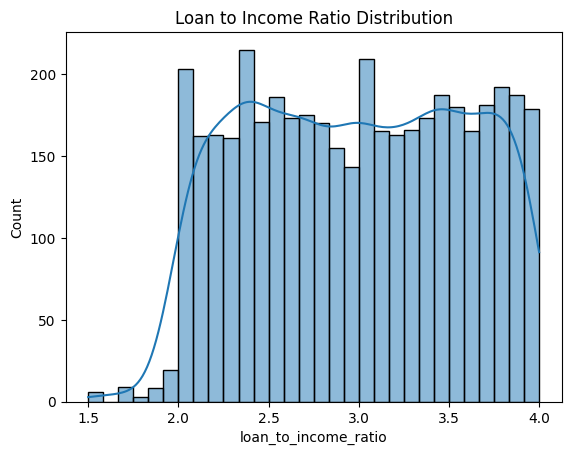

In [ ]:
# Distribution of loan_to_income_ratio
sns.histplot(df['loan_to_income_ratio'], bins=30, kde=True)
plt.title("Loan to Income Ratio Distribution")
plt.show()


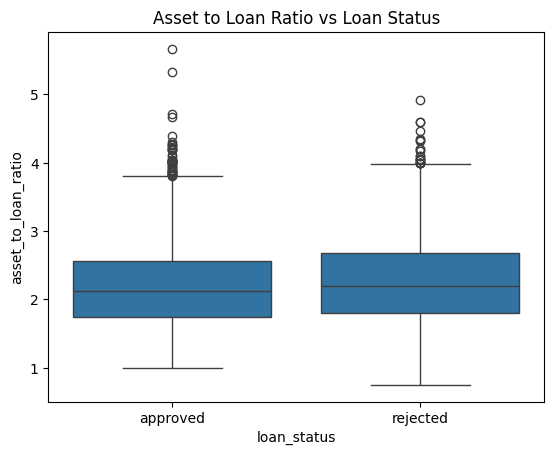

In [ ]:
# Asset to loan ratio by loan status
sns.boxplot(x='loan_status', y='asset_to_loan_ratio', data=df)
plt.title("Asset to Loan Ratio vs Loan Status")
plt.show()


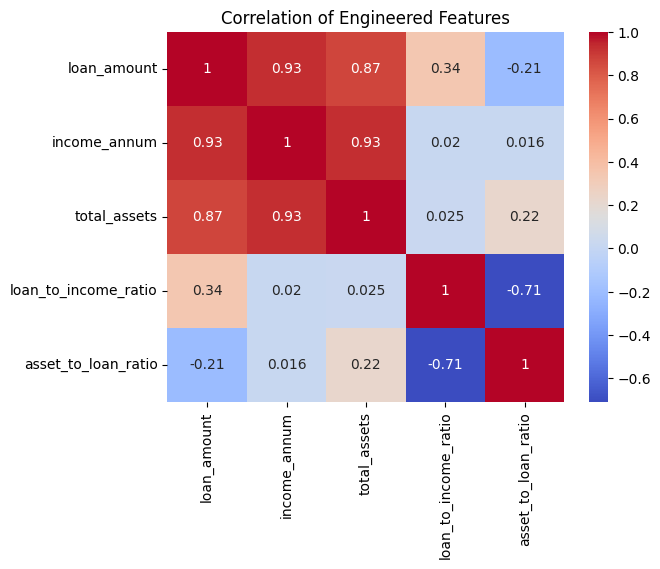

In [ ]:
# Correlation heatmap of engineered features
corr = df[['loan_amount', 'income_annum',
           'total_assets', 'loan_to_income_ratio',
           'asset_to_loan_ratio']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Engineered Features")
plt.show()


**SPLITTING FEATURES AND TARGET**

**DESCRIPTION:**

Separate independent features (X) and target variable (y). Convert loan_status to binary.

1.loan_id is removed because it does not contribute to prediction.

2.loan_status is the target variable.

3.Target is converted to binary:

A.approved → 1

B.rejected → 0

4.Binary encoding is necessary for classification algorithms.

In [ ]:
X = df.drop(columns=['loan_id', 'loan_status'])
y = df['loan_status']
y = y.map({'rejected': 0, 'approved': 1})



**PREPROCESSING PIPELINES**

**DESCRIPTION:**

Define separate preprocessing for numerical and categorical features.
1.Categorical features:
A.education, self_employed

2.Numerical features:

A.All remaining columns.

B.Preprocessing Steps

3.StandardScaler:

A.Normalizes numeric values

B.Improves model convergence

4.OneHotEncoder:

A.Converts categorical data into dummy variables

B.drop='first' avoids multicollinearity

C.ColumnTransformer applies these steps efficiently.


In [ ]:
categorical_features = ['education', 'self_employed']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)


**TRAIN RANDOM FOREST WITH SMOTE**

**DESCRIPTION:**

Split dataset into training and test sets, then create a pipeline with preprocessing, SMOTE, and Random Forest.

1.Dataset is split into:

A.80% training

B.20% testing

Stratification preserves class proportions.

2.Random Forest:

Uses 200 trees

class_weight='balanced' reduces bias toward majority class.

3.SMOTE:

Generates synthetic samples for minority class.

4.Pipeline ensures:

Preprocessing

Oversampling

Training occur in correct order.

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
# Pipeline: preprocessing + SMOTE + model
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),  # encoding + scaling
    ('smote', SMOTE(random_state=42)),
    ('model', rf_model)
])
# Train the model
pipeline.fit(X_train, y_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value',
                                                   'total_assets',
                                                   'loan_to_income_ratio',
                                                   'asset_to_loan_ratio']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['education',
                                                   'self_employed'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

**HYPERPARAMETER TUNING WITH GridSearchCV**

**DESCRIPTION:**

Tune Random Forest parameters using 5-fold cross-validation and ROC-AUC scoring.

1.GridSearchCV tests multiple combinations of:

A.Number of trees

B.Tree depth

C.Minimum samples split

D.5-fold cross-validation ensures stability.

2.ROC-AUC is used as scoring metric because:

A.It handles class imbalance well.

B.Best model is selected automatically.

In [ ]:
# Hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}
# Grid search
grid_search = GridSearchCV(
    estimator=pipeline,      # 👈 use the full pipeline
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
# Best model and parameters
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.9999890560875514


**MODEL EVALUATION**

**DESCRIPTION:**

Predict test data and evaluate using accuracy, precision, recall, and F1-score.

A. Predictions:

1.Class labels

2.Probabilities

B.  Metrics:

1.Accuracy shows overall correctness.

C. Classification report shows:

1.Precision

2.Recall

3.F1-score

These metrics help assess model reliability.

In [ ]:
# Predictions
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9988290398126464

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



**CONFUSION MATRIX**

**DESCRIPTION:**

Visualize correct and incorrect predictions.
A. Shows:

1.True Positives

2.True Negatives

3.False Positives

4.False Negatives

B. Heatmap improves interpretability.

C. Helps assess real-world impact of errors.

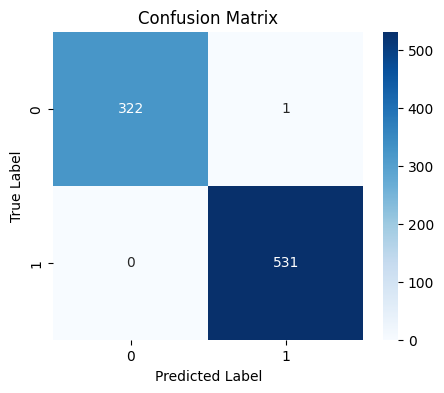

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**ROC Curve**

**DESCRIPTION:**

Visualize model's ability to distinguish between approved and rejected loans.

1.ROC curve plots:

False Positive Rate vs True Positive Rate

2.AUC value:

Closer to 1 → better model

Diagonal line represents random guessing.

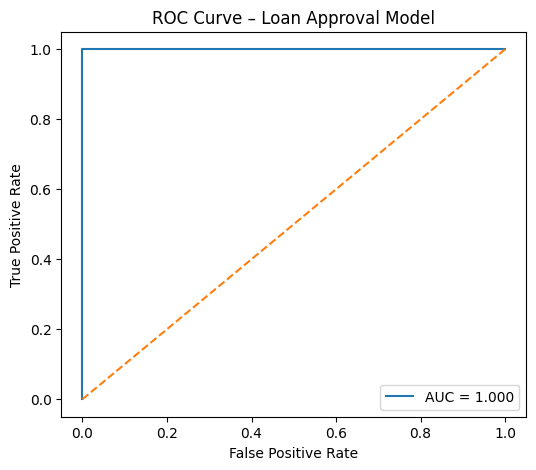

In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Loan Approval Model")
plt.legend()
plt.show()


**FEATURE IMPORTANCE**

**DESCRIPTION:**

 Extract feature importances from the Random Forest model and visualize the top 10.

1.Feature names extracted after preprocessing.

2.Random Forest provides importance scores.

3.Top 10 features are visualized.

Helps explain:

*Model decisions

*Business reasoning

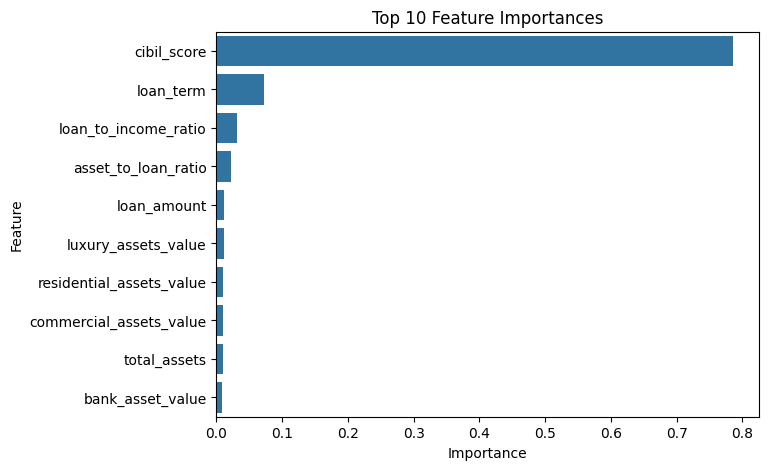

In [ ]:
# Feature names after preprocessing
num_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['num'].get_feature_names_out(numerical_features)

cat_features = best_model.named_steps['preprocessor'] \
    .named_transformers_['cat'].get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_features, cat_features])

# Get feature importances
importances = best_model.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(7, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()


**SAVING MODEL**

**DESCRIPTION:**

Save the trained pipeline (preprocessing + model) for future use.

1.Entire pipeline (preprocessing + model) is saved.

2.joblib.dump ensures efficient serialization.

3.Model can be reused without retraining.

In [ ]:
import joblib

joblib.dump(best_model, "loan_approval_model.pkl")
print("Final model saved as loan_approval_model.pkl")


Final model saved as loan_approval_model.pkl


In [ ]:
# Display top 5 features for presentation
print("Top 5 Features Influencing Loan Approval:")
print(fi_df.head(5))


Top 5 Features Influencing Loan Approval:
                 Feature  Importance
4            cibil_score    0.785916
3              loan_term    0.072824
10  loan_to_income_ratio    0.031445
11   asset_to_loan_ratio    0.021510
2            loan_amount    0.011475


**Model Performance Summary**
- **Best Model:** Random Forest Classifier with hyperparameter tuning.
- **Best Hyperparameters:** {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
- **Evaluation Metrics on Test Set:**
    - Accuracy:0.9988290398126464
    - ROC-AUC:0.9999890560875514
    - Precision, Recall, F1-Score:
      precision    recall  f1-score

                               0       1.00      1.00      1.00       
                               1       1.00      1.00      1.00       
- Confusion Matrix indicates how many loans were correctly predicted as approved/rejected.

**Key Feature Insights**
- Top 5 important features influencing loan approval:
    1. `cibil_score`
    2. `loan_term`
    3. `loan_to_income_ratio`
    4. `asset_to_loan_ratio`
    5. `loan_amount`
- **Financial ratios** such as `loan_to_income_ratio` and `asset_to_loan_ratio` are strong indicators of approval.

**Business Insights**
- Applicants with higher **total assets** relative to their loan amount are more likely to get approved.
- Applicants with lower **loan-to-income ratios** are safer bets for loan approval.
- **Education level** and **self-employment status** also impact approval probability.
- The model can help the bank **automate preliminary loan approvals**, reducing manual evaluation time and risk.

**Next Steps**
- Use the saved model (`loan_approval_model.pkl`) for real-time predictions in the loan processing system.
- Collect more data for applicants with borderline ratios to improve model performance.
- Periodically retrain the model to adapt to changing financial patterns.
